In [1]:
# Install pandas into the current Python environment (run this cell once), then import it
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
import pandas as pd
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "datasets"])
import matplotlib.pyplot as plt
from datasets import load_dataset
import sys, subprocess
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\Admin\anaconda3\envs\python_data\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_us = df[df['job_country'] == 'United States'].copy()
df_us['job_posted_month'] = df_us['job_posted_date'].dt.strftime('%B')
df_us_pivot = df_us.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')
df_us_pivot.reset_index(inplace=True)
df_us_pivot['month_number'] = pd.to_datetime(df_us_pivot['job_posted_month'], format='%B').dt.month
df_us_pivot.sort_values('month_number', inplace=True)
df_us_pivot.set_index('job_posted_month', inplace=True)
df_us_pivot.drop(columns='month_number', inplace=True)
df_us_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [3]:
df_software_pivot = pd.read_csv("https://lukeb.co/software_csv",index_col='job_posted_month')  
df_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [5]:
df_usdata = df_us_pivot.merge(df_software_pivot,on='job_posted_month')

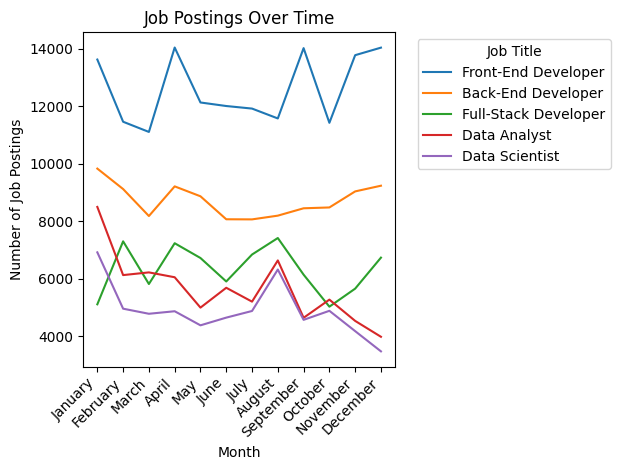

In [24]:

top_5 = df_usdata.sum().sort_values(ascending=False).head(5)
top_5 = top_5.index.tolist()

df_usdata[top_5].plot(kind='line')

plt.title('Job Postings Over Time') 
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')

# Fix legend
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show all months
plt.xticks(
    ticks=range(len(df_usdata.index)),
    labels=df_usdata.index,
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()